In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [2]:
# Путь к файлу botsv1.json
file_path = "botsv1.json"

# Загрузка JSON
with open(file_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# Извлечение поля result
records = [entry["result"] for entry in raw_data if "result" in entry]

# Создание DataFrame
df = pd.DataFrame(records)

# Приведение названий столбцов к единому регистру
df.columns = df.columns.str.lower()

# Приведение числовых полей к числовому типу
if "eventcode" in df.columns:
    df["eventcode"] = pd.to_numeric(df["eventcode"], errors="coerce")

# Очистка от пустых значений
df = df.dropna(how="all")

print("Размер датасета:", df.shape)
print(df.head())

Размер датасета: (38, 115)
                 account_domain              account_name  \
0                  WAYNECORPINC                we3436srv$   
1                  WAYNECORPINC                we1159srv$   
2             [-, WAYNECORPINC]           [-, we9028srv$]   
3  [WAYNECORPINC, WAYNECORPINC]  [we5878srv$, we5878srv$]   
4  [WAYNECORPINC, WAYNECORPINC]  [we3997srv$, we3997srv$]   

                   computername creator_process_id  eventcode eventtype  \
0  we3436srv.waynecorpinc.local              0xddc     4688.0         0   
1  we1159srv.waynecorpinc.local                NaN     4689.0         0   
2  we9028srv.waynecorpinc.local                NaN     4624.0         0   
3  we5878srv.waynecorpinc.local                NaN     4703.0         0   
4  we3997srv.waynecorpinc.local                NaN     4703.0         0   

        keywords   logname          logon_id  \
0  Audit Success  Security             0x3E7   
1  Audit Success  Security             0x3E7   
2  Audit Su

In [3]:
suspicious_event_ids = [4625, 4672, 4688, 4720]

winevent_df = df[df["logname"].str.lower() == "security"]

suspicious_winevents = winevent_df[
    winevent_df["eventcode"].isin(suspicious_event_ids)
]

winevent_counts = suspicious_winevents["eventcode"].value_counts()

print("Подозрительные WinEventLog события:")
print(winevent_counts)

Подозрительные WinEventLog события:
eventcode
4688.0    9
Name: count, dtype: int64


In [5]:
dns_df = df[df["logname"].str.lower().str.contains("dns", na=False)]

# Функция определения подозрительного домена
def is_suspicious_domain(domain):
    if not isinstance(domain, str):
        return False
    
    # длинный домен
    if len(domain) > 50:
        return True
    
    # слишком много поддоменов
    if domain.count('.') > 4:
        return True
    
    # случайные строки (много цифр)
    if re.search(r'[a-zA-Z0-9]{15,}', domain):
        return True
    
    return False


# Предполагаем, что поле message содержит домен
dns_df = df[df["logname"].str.lower().str.contains("dns", na=False)].copy()

dns_df["suspicious"] = dns_df["message"].apply(is_suspicious_domain)

suspicious_dns = dns_df[dns_df["suspicious"] == True]

# Подсчёт наиболее частых подозрительных доменов
dns_counts = suspicious_dns["message"].value_counts().head(10)

print("Топ подозрительных DNS-запросов:")
print(dns_counts)

Топ подозрительных DNS-запросов:
message
DNS query executed.\n\nQuery Information:\n\tQuery Name:\tgoogle.com\n\tQuery Type:\tA\n\tClient IP:\t192.168.1.25\n\tResponse Code:\tNOERROR                1
DNS query executed.\n\nQuery Information:\n\tQuery Name:\tajd92jd9d.com\n\tQuery Type:\tA\n\tClient IP:\t192.168.1.77\n\tResponse Code:\tNOERROR             1
DNS query executed.\n\nQuery Information:\n\tQuery Name:\tc2.maliciousdomain.com\n\tQuery Type:\tA\n\tClient IP:\t192.168.1.88\n\tResponse Code:\tNOERROR    1
Name: count, dtype: int64


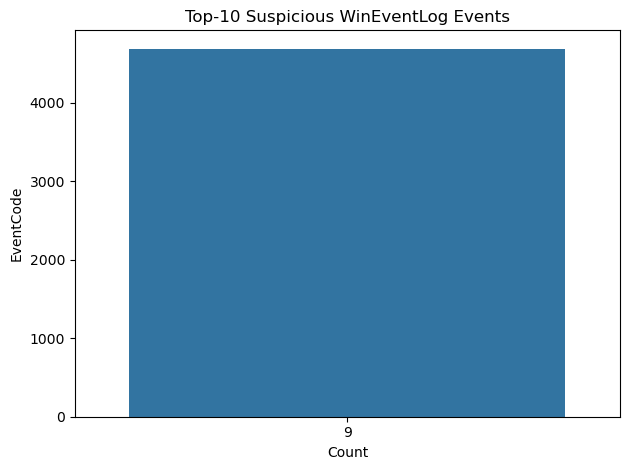

In [6]:
plt.figure()
sns.barplot(
    x=winevent_counts.head(10).values,
    y=winevent_counts.head(10).index
)
plt.title("Top-10 Suspicious WinEventLog Events")
plt.xlabel("Count")
plt.ylabel("EventCode")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
sns.barplot(
    x=dns_counts.values,
    y=dns_counts.index
)
plt.title("Top-10 Suspicious DNS Queries")
plt.xlabel("Count")
plt.ylabel("Domain")
plt.tight_layout()
plt.show()